# CDR-Selective Resampling for Boltz-2 — Colab runner

End-to-end proof of concept on three nanobody–antigen complexes.
Runtime: **GPU (A100 or L4)**. Set it with *Runtime → Change runtime type → GPU*.

| Stage | What it does | Approx. time (A100) |
|---|---|---|
| Setup | install Boltz-2, clone this repo | ~5 min (weights download once, ~3 GB) |
| 0 | global dock with stock Boltz-2 — the **baseline** | ~4 min / target |
| A | template-masked CDR re-prediction | ~8 min / target |
| B | CDR-selective diffusion resampling (3 sub-arms) | ~12 min / target |
| Eval | metrics, ensemble diversity, scorer comparison | ~1 min, CPU |

Everything except the Boltz calls also runs on a laptop — see
`scripts/05_backward_pass_demo.py` for the forward/backward demonstration,
`scripts/07_cdr_selection_demo.py` for choosing which loops to resample, and
`scripts/06_synthetic_ensemble.py` for a GPU-free exercise of the whole analysis path.

## 1 · Setup

In [ ]:
!nvidia-smi --query-gpu=name,memory.total --format=csv

In [ ]:
# Clones this project into the Colab VM. If you have a fork, point REPO_URL at it; if you
# uploaded the folder to Drive instead, mount it and set REPO to that path.
REPO_URL = "https://github.com/bendorr/boltz-cdr.git"
REPO = "/content/boltz-cdr"

import os, subprocess, sys
if not os.path.exists(REPO):
    subprocess.run(["git", "clone", REPO_URL, REPO], check=True)
os.chdir(REPO)
print(os.getcwd())

In [ ]:
!pip install -q -r requirements-gpu.txt
# Boltz weights (~3 GB) download to ~/.boltz on the first prediction, not now.

In [ ]:
import sys
sys.path.insert(0, "src")
sys.path.insert(0, "scripts")

from boltz_cdr.run import describe_environment
describe_environment()

## 2 · Targets

Three nanobody–antigen complexes, all **released after Boltz-2's training cutoff**
(assumed 2023-06-01) so nothing here is memorized, all with fully-ordered CDR loops and
substantial interfaces. Validation prints the ground-truth interface statistics that the
predictions are later scored against.

In [ ]:
!python scripts/00_fetch_targets.py

## 3 · Run configuration

Everything the rest of the notebook needs, in one place.

`CDR_RESIDUES` is the interesting one. The CDRs are found automatically by an IMGT
annotator, and that is the default — but it is only a default. Set this to define the
loops yourself, in **author residue numbering** (the numbers you read off the structure
in PyMOL):

```
"E:28-35,53-60,99-117"     # positional -> CDR1, CDR2, CDR3
"E:cdr3=99-117"            # named; omit any loop you do not want resampled
"E:cdr3=99-110+114-117"    # '+' joins discontinuous stretches
```

Leave it as `None` to use the automatic annotation. Per-target definitions can also live
in `data/targets.yaml` under a `cdr_residues` block, with no flag needed. Precedence:
`--cdr-residues` > `cdr_residues` > `cdr_spans` (legacy, 0-based) > automatic.

In [ ]:
TARGETS = ["8QF4", "9EZU", "9HUR"]
SAMPLES = 8            # diffusion samples per run; raise if you have time budget

# e.g. CDR_RESIDUES = "E:cdr3=99-117"  -> resample only CDR3 of 8QF4
CDR_RESIDUES = None

DEMO_TARGET = TARGETS[0]          # the one the CPU demos below illustrate
target_args = " ".join(f"--target {t}" for t in TARGETS)
CDR_ARG = f'--cdr-residues "{CDR_RESIDUES}"' if CDR_RESIDUES else ""

print("targets        :", ", ".join(TARGETS))
print("samples per arm:", SAMPLES)
print("CDR definition :", CDR_RESIDUES or "automatic IMGT annotation")

### Which loops will actually be resampled?

This runs on CPU in a couple of seconds. It prints what the annotator selected as author
residue numbers — exactly what you would type into `CDR_RESIDUES` above — then proves that
feeding those same numbers back reproduces the annotation identically, compares three
realistic alternative definitions (CDR3 only, CDR3 widened to free its anchor residues,
and a discontinuous selection), and shows what a mis-numbered specification does.

The `paratope` column is the one to read: it counts how many of the antibody residues that
genuinely contact the antigen fall inside each definition. A definition that misses most
of the paratope will not resample the geometry that matters.

In [ ]:
!python scripts/07_cdr_selection_demo.py --target {DEMO_TARGET}

The choice is not cosmetic. It flows through the entire method: which residues are deleted
from the Arm A template, which atoms receive scaled noise and gradient guidance in Arm B,
and which residues the per-CDR RMSD metrics are computed over. Every number is validated
against the structure, so a typo halts the run instead of silently resampling the wrong
loop — author numbering is arbitrary (8QF4's antibody starts at residue 2, 9EZU's at 0).

## 4 · Forward and backward pass

Runs on CPU. Verifies the guidance potential on real coordinates: energy ~0 on the crystal
structure, energy rises when the interface is broken, gradients finite and confined to CDR
atoms, autograd matching central finite differences, and descent restoring the interface.

It honors `CDR_RESIDUES` too, so you can see the gradient confined to a loop set you chose.

In [ ]:
!python scripts/05_backward_pass_demo.py --target {DEMO_TARGET} --displacement 4.0 {CDR_ARG}

## 5 · Stage 0 — global docking (baseline arm)

Stock, unpatched Boltz-2. This is the null hypothesis both modified arms are measured
against, and it produces the docked poses Arms A and B build on.

`--steered` adds a second baseline using Boltz's own `--use_potentials`, which separates
"steering helps" from "*our* steering helps".

In [ ]:
!python scripts/01_global_dock.py {target_args} --samples {SAMPLES} --steered

## 6 · Arm A — template-masked CDR re-prediction

Writes each top-ranked pose back as a template with the CDR residues **deleted**, then
re-predicts. The framework–antigen pose is pinned; the loops are unconstrained.

`armA_control` templates the complete complex with nothing deleted. Without that control,
any diversity Arm A shows could just be template conditioning rather than the masking.

In [ ]:
!python scripts/02_arm_a_template_resample.py {target_args} --top-k 2 --samples {SAMPLES} {CDR_ARG}

## 7 · Arm B — CDR-selective diffusion resampling

Three sub-arms isolating each lever:

- `armB_noise` — B1, per-atom noise scaling on CDR atoms only
- `armB_partial` — B2, re-noise only the CDRs from a docked pose
- `armB_guided` — B1 + B3, plus the differentiable CDR–epitope potential

`armB_guided` is the arm where the backward pass runs inside the sampler: at every
guidance step Boltz calls `compute_gradient`, which evaluates our energy under
`torch.enable_grad()` and returns `dE/dx` masked to the CDR atoms.

In [ ]:
!python scripts/03_arm_b_diffusion_resample.py {target_args} --samples {SAMPLES} \
    --lambda-cdr 1.5 --partial-sigma 8.0 --guidance-weight 0.2 {CDR_ARG}

### Optional — resample a single loop

A concrete use of the override: spend the whole sampling budget on CDR3, which contributes
most of the paratope, instead of spreading it over all three loops. Compare the resulting
`cdr3_rmsd` and ensemble diversity against the run above.

In [ ]:
# !python scripts/03_arm_b_diffusion_resample.py --target 8QF4 --sub-arm armB_noise \
#     --samples {SAMPLES} --cdr-residues "E:cdr3=99-117" --results results_cdr3only

### Optional — epitope-directed generation

Restricting the potential to a named epitope turns the sampler into an epitope-directed
generator with no retraining. **`--epitope-from-native` is an oracle setting**: it reads
the answer out of the crystal structure. It demonstrates the capability; it is not a
benchmark arm. In a real campaign the epitope comes from mutagenesis, HDX, or a
competition assay.

In [ ]:
# !python scripts/03_arm_b_diffusion_resample.py --target 8QF4 --sub-arm armB_guided \
#     --samples {SAMPLES} --epitope-from-native --guidance-weight 0.4

## 8 · Evaluation

CPU only. Produces four tables under `results/analysis/`:

- `samples.csv` — every structure, every metric
- `arms.csv` — per-arm accuracy (the ablation)
- `ensembles.csv` — diversity and best-of-N coverage
- `scorers.csv` — **which selection score actually picks the best structure**

`CDR_ARG` is passed here too, so the per-CDR RMSD columns are reported over the same loop
definition that was resampled.

In [ ]:
!python scripts/04_evaluate.py {target_args} {CDR_ARG}

## 9 · Visualizing the ensemble

Two views of the same structures, both driven by `results/analysis/samples.csv`, so they
describe exactly the ensemble the tables above were computed from.

`notebooks/cdr_ensemble_visualization.ipynb` is a standalone CPU-only version of these two
cells, committed with its outputs, applied to a 20-model NMR ensemble of a nanobody. It is
worth a look before running this section: it shows what the plots look like when the
underlying loop diversity is experimentally measured rather than predicted.

**The two figures below are placeholders.** They are committed already executed, so the
section is not blank in the repository, but they were drawn from ten NMR models that ship
with the repo (`EXAMPLE_ENSEMBLE` in the next cell) rather than from any prediction. Run
this notebook and they are replaced by your own Boltz-2 structures.

In [4]:
import pandas as pd, numpy as np
from boltz_cdr.pdb_io import load_complex
from boltz_cdr.yaml_io import ANTIBODY_CHAIN_ID, ANTIGEN_CHAIN_ID
from _common import load_targets

# Placeholder mode. Leave it False for a real run: the figures below are then drawn from
# this notebook's own predictions, and the committed placeholders are overwritten. Set it
# True to redraw those placeholders from the ten committed NMR models, which needs no GPU,
# no Boltz-2 weights and no results/ directory.
EXAMPLE_ENSEMBLE = False
EXAMPLE_PATH = "data/examples/9kfw_10models.pdb.gz"

VIEW_TARGET = DEMO_TARGET
VIEW_ARMS = None          # e.g. ["armA", "armB_guided"]; None uses every arm
COLOR_BY = "conf_iptm"    # any column of samples.csv

if EXAMPLE_ENSEMBLE:
    from boltz_cdr.cdr import annotate_vhh
    from boltz_cdr.metrics.interface import sasa
    from boltz_cdr.pdb_io import load_models

    VIEW_TARGET = "9KFW example ensemble"
    structures = load_models(EXAMPLE_PATH)
    annotation = annotate_vhh(structures[0].seq)

    # A deposited ensemble has no confidence and no DockQ, so the quantity plotted is a
    # conformational property instead: how much CDR surface each model exposes.
    COLOR_BY = "CDR SASA (A^2)"
    cdr_atoms = structures[0].atom_mask_for_residues(annotation.all_indices)
    selected = pd.DataFrame({
        "arm": "9KFW NMR models",
        COLOR_BY: [
            sasa(s.coords, s.atom_elements, n_points=96)[cdr_atoms].sum()
            for s in structures
        ],
    })
    print(f"PLACEHOLDER: {EXAMPLE_PATH} — set EXAMPLE_ENSEMBLE = False and rerun this "
          f"notebook to draw your own predictions instead")
else:
    samples = pd.read_csv("results/analysis/samples.csv")
    selected = samples[samples.target == VIEW_TARGET]
    if VIEW_ARMS:
        selected = selected[selected.arm.isin(VIEW_ARMS)]
    selected = selected.reset_index(drop=True)

    target = load_targets(only=[VIEW_TARGET], cdr_residues=CDR_RESIDUES)[0]
    structures = [
        load_complex(p, ANTIBODY_CHAIN_ID, ANTIGEN_CHAIN_ID) for p in selected["path"]
    ]
    annotation = target.annotation_for(structures[0].antibody.seq)

print(f"{len(structures)} structures from arms: {', '.join(sorted(selected.arm.unique()))}")
print(f"CDRs: {annotation.summary()}")

PLACEHOLDER: data/examples/9kfw_10models.pdb.gz — set EXAMPLE_ENSEMBLE = False and rerun this notebook to draw your own predictions instead
10 structures from arms: 9KFW NMR models
CDRs: CDR1[8]=GFTLDYYA  CDR2[8]=ISSSGGST  CDR3[23]=AAVDDVGTTVQAMAVHEPYEYDY


### Structural overlay

Every member's CDR loops, superposed on a shared antibody framework and drawn over a
single muted copy of the framework and antigen. Because the superposition is on the
framework, the spread on screen is loop conformation; rigid-body placement has been
removed. Color runs red to purple along an ordering of the members by structural
similarity, so similarly-shaped loops take similar colors; `COLOR_BY` supplies the number
shown beside each member in the legend. Pass `color_by="value"` to color by it instead.

Rotate with the mouse. The controls under the viewer toggle side chains, switch
side-chain coloring between the member's own color and per-element colors (N blue, O red,
S yellow, with carbon keeping the member color), hide the shared framework and antigen,
and show or hide individual members from the legend.

Pass `max_overlay=N` to thin a large ensemble, and `align_on="antigen"` to superpose on
the target instead, which puts rigid-body placement back into the picture.

The viewer is JavaScript, so GitHub's notebook preview — which strips scripts — shows the
saved output as an empty frame above a dead legend. Colab, Jupyter, VSCode and nbviewer
all render it; the landscape below is a plain image and shows up anywhere.

In [5]:
from boltz_cdr.visualize import ensemble_view

view = ensemble_view(
    structures,
    annotation,
    values=selected[COLOR_BY].to_numpy(),
    max_overlay=24,
)
view.show()

<EnsembleView: 10 members>

### Conformation landscape

The same loops projected to two dimensions, with a third quantity raised over the plane
and smoothed into a surface. With `Z_COLUMN` set to a confidence measure the result is
read like an energy landscape, the reaction coordinate replaced by a reduced description
of loop conformation. Setting it to `dockq` instead shows true accuracy over the same
plane, and the difference between the two surfaces is precisely the question the scorer
comparison asks.

The projection is PCA by default; the axis labels report how much of the ensemble's
variance the two components capture, which is the honest caveat on any such plot. Passing
`method="mds"` runs classical multidimensional scaling on pairwise CDR RMSD instead, which
can represent an ensemble that is not well described by two linear modes.

The surface is a kernel average, not an interpolant, so it cannot exceed the range of the
observed values, and it is masked wherever no structure lies close enough to support it.
The structures themselves are always drawn on top, so the density of evidence behind any
feature is visible.

Each point carries both readings at once, as the key under the panels says: it is
**filled** with the color that structure has in the overlay above — so run the cell above
first, and trace any feature here back to a specific member's loops — and **ringed** with
its `Z_COLUMN` value on the surface's own scale, so a ring that matches the surface beneath
it is a point the smoothing reproduces.

PC1+PC2 capture 65% of the conformational variance
kernel bandwidth 15.00; 100% of the plane supported
39 CDR residues compared across all members


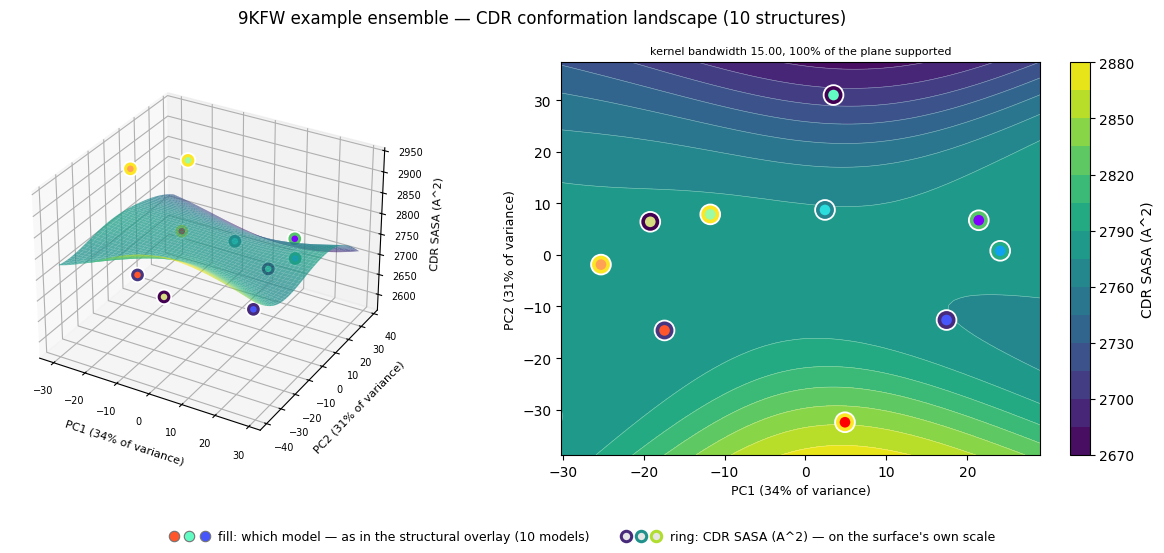

In [6]:
import pathlib
from boltz_cdr.visualize import conformation_landscape, plot_landscape

Z_COLUMN = "conf_iptm"     # try "dockq", "shape_complementarity", "conf_complex_plddt"
if EXAMPLE_ENSEMBLE:
    Z_COLUMN = COLOR_BY    # the example ensemble carries only the one quantity

landscape, projection, coords = conformation_landscape(
    structures,
    annotation,
    selected[Z_COLUMN].to_numpy(),
    method="pca",          # or "mds"
)
fig, _ = plot_landscape(
    landscape,
    projection,
    value_label=Z_COLUMN,
    title=f"{VIEW_TARGET} — CDR conformation landscape ({len(structures)} structures)",
    # Fill each point with the color its loops have in the overlay above, so a feature here
    # can be traced to a structure there. Only possible when the overlay drew every
    # member — raise `max_overlay` if it thinned the ensemble.
    point_colors=view.colors if len(view.colors) == len(structures) else None,
)
pathlib.Path("results/analysis").mkdir(parents=True, exist_ok=True)
fig.savefig("results/analysis/cdr_landscape.png", dpi=150, bbox_inches="tight")

print(f"PC1+PC2 capture {projection.explained_variance.sum():.0%} of the conformational variance")
print(f"kernel bandwidth {landscape.bandwidth:.2f}; {landscape.coverage:.0%} of the plane supported")
print(f"{len(coords.residue_indices)} CDR residues compared across all members")

Both cells work for any number of structures. If the surface appears as separate islands,
the ensemble contains structural outliers far from the main cluster — informative in
itself, and visible as isolated points in the contour panel.

## 10 · Figures

In [ ]:
import pandas as pd, matplotlib.pyplot as plt, numpy as np

samples = pd.read_csv("results/analysis/samples.csv")
ensembles = pd.read_csv("results/analysis/ensembles.csv")
scorers = pd.read_csv("results/analysis/scorers.csv")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# DockQ distribution per arm
arms = sorted(samples["arm"].unique())
axes[0].boxplot([samples.loc[samples.arm == a, "dockq"].dropna() for a in arms], labels=arms)
for threshold, label in ((0.23, "acceptable"), (0.49, "medium"), (0.80, "high")):
    axes[0].axhline(threshold, ls="--", lw=0.8, color="gray")
    axes[0].text(0.55, threshold + 0.01, label, fontsize=7, color="gray")
axes[0].set_ylabel("DockQ"); axes[0].set_title("Accuracy by arm")
axes[0].tick_params(axis="x", rotation=45)

# Diversity vs coverage
for arm in arms:
    row = ensembles[ensembles.arm == arm]
    axes[1].scatter(row["mean_pairwise_cdr3_rmsd"], row["best_dockq"], s=70, label=arm)
axes[1].set_xlabel("mean pairwise CDR3 RMSD (A)  — diversity")
axes[1].set_ylabel("best-of-N DockQ  — coverage")
axes[1].set_title("Does extra diversity buy coverage?")
axes[1].legend(fontsize=7)

# Scorer ranking power
top = scorers.head(10).iloc[::-1]
colors = ["tab:blue" if s.startswith("conf") else "tab:orange" for s in top["scorer"]]
axes[2].barh(top["scorer"], top["top1_dockq"], color=colors)
axes[2].axvline(scorers["mean_dockq"].iloc[0], ls="--", color="gray", label="random pick")
axes[2].axvline(scorers["oracle_dockq"].iloc[0], ls="-", color="black", label="oracle")
axes[2].set_xlabel("DockQ of the top-1 pick"); axes[2].set_title("Which scorer selects well?")
axes[2].legend(fontsize=7); axes[2].tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.savefig("results/analysis/summary.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Confidence vs physics, colored by true quality — the scorer-disagreement picture.
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(samples["conf_iptm"], samples["shape_complementarity"],
                c=samples["dockq"], cmap="viridis", s=45, edgecolor="k", linewidth=0.3)
ax.set_xlabel("Boltz ipTM  (model confidence)")
ax.set_ylabel("shape complementarity Sc  (physics)")
ax.set_title("Where the two scorer families disagree")
plt.colorbar(sc, label="true DockQ")
plt.tight_layout(); plt.show()

## 11 · Save results

The analysis tables are small; the structures are not. Download just the tables, or copy
the whole `results/` tree to Drive if you want to re-analyze later — `04_evaluate.py`
runs on a laptop against a saved `results/` directory.

In [ ]:
!cd results && zip -qr /content/analysis.zip analysis && echo "wrote /content/analysis.zip"
from google.colab import files
files.download("/content/analysis.zip")